In [419]:
import pandas as pd
import numpy as np

import warnings

warnings.filterwarnings("ignore")

from dataclasses import dataclass

In [420]:
import subprocess

FLEET_SIZES = (15000,)

args = ["./sim"]
for fleet_size in FLEET_SIZES:
    with open(f"data/sim_configs/ann-arbor-{fleet_size}.txt", "w") as f:
        f.write(f"length: {24 * 7 * 3600}\n")
        f.write(f"requests: data/requests/ann-arbor.parquet\n")
        f.write(f"riders: data/riders/ann-arbor-{fleet_size}.parquet\n")
        f.write(f"output: output/ann-arbor-{fleet_size}.parquet\n")

        f.write(f"fm_cutoff_km: 1000\n")

        f.write(f"ev_charge_range: 400\n")
        f.write(f"ev_charge_time: 5400\n")
        f.write(f"ev_charge_threshold: 0.2\n")
        f.write(f"ev_charge_to: 0.8\n")

    args.append(f"ann-arbor-{fleet_size}")

subprocess.run(["cmake", "--build", "cmake-build-release", "--target", "sim", "-j", "8"], check=True)
subprocess.run(args, check=True)

[ 10%] Built target tqdm
[ 26%] Built target pandas
[100%] Built target sim
reading data/requests/ann-arbor.parquet
reading data/riders/ann-arbor-15000.parquet
Elapsed time: 33750 milliseconds



CompletedProcess(args=['./sim', 'ann-arbor-15000'], returncode=0)

In [421]:
fleet_size = 15000

requests = pd.read_parquet(f"data/requests/ann-arbor.parquet")
riders = pd.read_parquet(f"data/riders/ann-arbor-{fleet_size}.parquet")
output = pd.read_parquet(f"output/ann-arbor-{fleet_size}.parquet")

output = requests.merge(output, left_index=True, right_index=True, validate="1:1")

output = output[output["completed"]]
output["response_time"] = output["arrived_pickup_at"] - output["created_at"]
output["fm_time"] = output["arrived_pickup_at"] - output["start_at"]
output["pickup_time"] = output["pickedup_at"] - output["arrived_pickup_at"]
output["lm_time"] = output["arrived_drop_at"] - output["pickedup_at"]
output["drop_time"] = output["completed_at"] - output["arrived_drop_at"]

output.head()

,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,pick_hex,drop_hex,predicted_lm_dist,completed,...,arrived_pickup_at,pickedup_at,arrived_drop_at,completed_at,assigned_rider,response_time,fm_time,pickup_time,lm_time,drop_time
0,1,0.738192,-1.461150,0.737894,-1.461245,1,604233477973344255,604233477973344255,3.059599,True,...,58,229,504,675,5488,57,57,171,275,171
1,1,0.737452,-1.461878,0.737590,-1.462015,1,604173502378934271,604173502378934271,1.955007,True,...,57,228,403,574,7452,56,56,171,175,171
2,2,0.737938,-1.461433,0.737510,-1.462187,1,604173502378934271,604173502378934271,6.280482,True,...,55,226,791,962,4491,53,53,171,565,171
3,2,0.738500,-1.461484,0.738373,-1.461333,1,604233477973344255,604233477973344255,1.942169,True,...,60,231,405,576,14178,58,58,171,174,171
4,3,0.737985,-1.461830,0.737917,-1.461856,1,604173502378934271,604173502378934271,1.142364,True,...,58,229,331,502,10940,55,55,171,102,171


In [426]:
from ev_sim.plot import *
import matplotlib.pyplot as plt


@dataclass
class SeriesStyling:
    label: str
    color: str


styles = {
    "fm_time": SeriesStyling("FM Time", color="#429cf5"),
    "lm_time": SeriesStyling("LM Time", color="#f2506e"),
    "response_time": SeriesStyling("Response Time", color="#f5a742"),

    "fm_dist": SeriesStyling("FM Distance", color="#429cf5"),
    "lm_dist": SeriesStyling("LM Distance", color="#f2506e"),
    "predicted_lm_dist": SeriesStyling("LM Distance (Predicted)", color="#f5a742"),

    "pick_lat": SeriesStyling("Pickup Latitude", color="#429cf5"),
    "drop_lat": SeriesStyling("Drop Latitude", color="#f2506e"),
}

In [423]:
def _map_values_to_slot(v, xmin, xmax, left, right):
    # maps v in [xmin,xmax] -> v' in [left,right]
    return left + (v - xmin) * (right - left) / (xmax - xmin)


def plot_histogram_on_axis(data, ax, title: str = "", bins: int = 100, subtitle: str = "",
                           legend: bool = None, minimal: bool = False, **kwargs):
    series = data.columns

    ax.hist([data[s] for s in series],
            color=[styles[s].color for s in series],
            label=[styles[s].label for s in series],
            stacked=True, bins=bins, **kwargs)

    if minimal:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)

    if legend is True or not minimal:
        ax.legend()

    style_plot(ax, title=title, subtitle=subtitle)


def plot_evolving_histograms(data, index, title: str, k: int = 6, subtitle: str = ""):
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.2, wspace=0.1)

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax2_hist = ax2.twinx()

    # ----------------
    # main histogram
    ax1.set_yticklabels([])
    plot_histogram_on_axis(data, ax1, title=title, subtitle=subtitle, bins=200)

    # ----------------
    # rolling mean plot
    for s in data.columns:
        y = pd.Series(data[s].values, index=index).sort_index()
        bins = np.linspace(index.min(), index.max(), 100)

        y_rm = y.groupby(pd.cut(y.index, bins=bins)).mean()
        x = bins[:-1][:len(y_rm)]

        ax2.plot(x, y_rm, color=styles[s].color, linewidth=1.5, label=styles[s].label)

    style_plot(ax2, title="", grid_color="#fff")

    # ----------------
    # smaller panel of evolving histograms
    bins_per_slot = 50
    edges = np.linspace(index.min(), index.max(), k + 1)

    for i in range(k):
        left, right = edges[i], edges[i + 1]
        mask = (index >= left) & (index < right)

        mock = []
        for s in data.columns:
            xmin = np.quantile(data[s], 0.01) * 0.5
            xmax = np.quantile(data[s], 0.99) * 1.5

            v = data.loc[mask, s].to_numpy()
            v = v[(v > xmin) & (v < xmax)]
            mock.append(_map_values_to_slot(v, xmin, xmax, left, right))

        slot_bins = np.linspace(left, right, bins_per_slot + 1)
        ax2_hist.hist(mock, bins=slot_bins, stacked=True, color=[styles[s].color for s in data.columns], alpha=0.4)

    style_plot(ax2_hist, title="")
    ax2_hist.yaxis.set_visible(False)


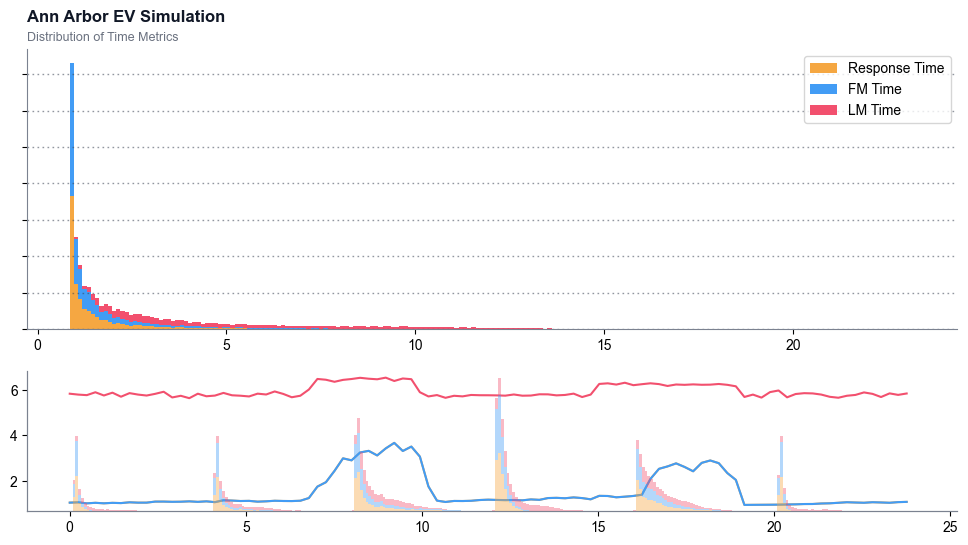

In [424]:
plot_evolving_histograms(output[["response_time", "fm_time", "lm_time"]] / 60, output["start_at"] / 3600,
                         title="Ann Arbor EV Simulation", subtitle="Distribution of Time Metrics", k=6)

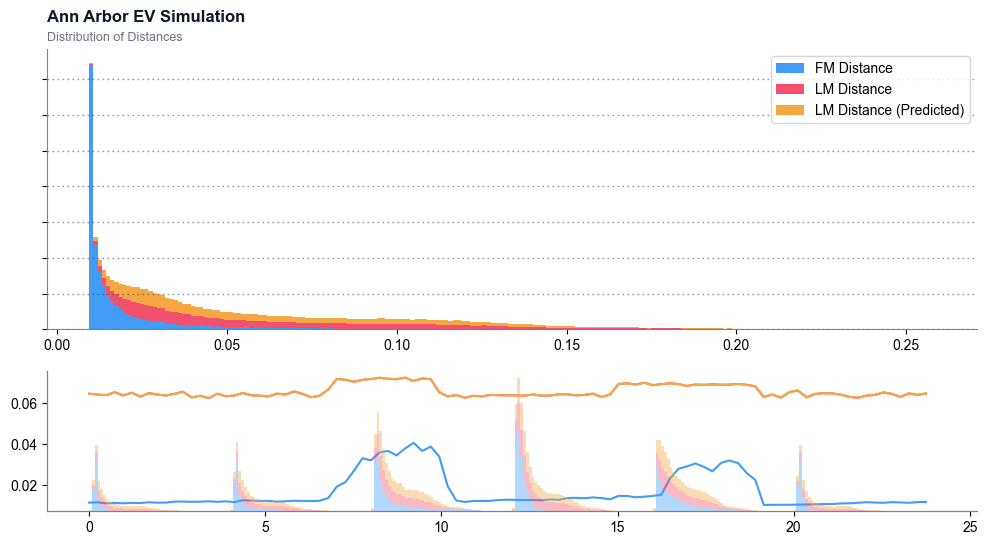

In [427]:
plot_evolving_histograms(output[["fm_dist", "lm_dist", "predicted_lm_dist"]] / 60, output["start_at"] / 3600,
                         title="Ann Arbor EV Simulation", subtitle="Distribution of Distances", k=6)